In [1]:
# =============================================================================
# CELL 1 — SETUP
# =============================================================================

import glob
import re
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.tri as mtri
import pickle
import pandas as pd
import matplotlib.lines as mlines

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif']  = ['cmr10', 'Computer Modern Roman', 'DejaVu Serif']
matplotlib.rcParams['axes.formatter.use_mathtext'] = True

# ── paths ─────────────────────────────────────────────────────────────────────
DATA_PATH     = Path("/mnt/storage7/clark/NEMO/Simulations/ARC60/Model_Runs/ARC60-ECP004")
EKE_PATH      = Path("/mnt/storage7/clark/NEMO/Analysis/ARC60/EKE_percell/NcFiles/IndividualDays")
PROCESSED_DIR = Path("../processedData")
FIGURES_DIR   = Path("../figures")
PROCESSED_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# ── year range ────────────────────────────────────────────────────────────────
YEAR_START = 1993
YEAR_END   = 1999

# ── target depths and integration boundaries ──────────────────────────────────
TARGET_DEPTHS = [0, 50, 100, 200]
DEPTH_BOUNDARIES = {
    50:  (0,   50),
    100: (50,  100),
    200: (100, 200),
}

# ── season definitions ────────────────────────────────────────────────────────
SEASONS = {
    'JFM': [1, 2, 3],
    'AMJ': [4, 5, 6],
    'JAS': [7, 8, 9],
    'OND': [10, 11, 12],
}

# ── bounding box ──────────────────────────────────────────────────────────────
CROP_LON_MIN, CROP_LON_MAX = -180, -110
CROP_LAT_MIN, CROP_LAT_MAX =   65,   85

# ── file discovery ────────────────────────────────────────────────────────────
_DATE_RE_UV = re.compile(r'_y(\d{4})m(\d{2})d(\d{2})_grid[UV]')
_DATE_RE_T  = re.compile(r'_y(\d{4})m(\d{2})d(\d{2})_gridT')
_DATE_RE_EKE = re.compile(r'EKE_y(\d{4})m(\d{2})d(\d{2})')

def _parse_date_re(filepath, regex):
    m = regex.search(Path(filepath).name)
    if m:
        return int(m.group(1)), int(m.group(2)), int(m.group(3))
    return None

def _build_file_index(files, regex, y0, y1):
    index = {}
    for f in files:
        parsed = _parse_date_re(f, regex)
        if parsed:
            y, mo, d = parsed
            if y0 <= y <= y1:
                index[datetime(y, mo, d)] = f
    return dict(sorted(index.items()))

all_u   = glob.glob(str(DATA_PATH / "gridU"  / "*_gridU.nc"))
all_v   = glob.glob(str(DATA_PATH / "gridV"  / "*_gridV.nc"))
all_t   = glob.glob(str(DATA_PATH / "gridT"  / "*_gridT.nc"))
all_eke = glob.glob(str(EKE_PATH  / "*.nc"))

u_index   = _build_file_index(all_u,   _DATE_RE_UV,  YEAR_START, YEAR_END)
v_index   = _build_file_index(all_v,   _DATE_RE_UV,  YEAR_START, YEAR_END)
t_index   = _build_file_index(all_t,   _DATE_RE_T,   YEAR_START, YEAR_END)
eke_index = _build_file_index(all_eke, _DATE_RE_EKE, YEAR_START, YEAR_END)

common_dates     = sorted(set(u_index)   & set(v_index))
common_dates_t   = sorted(set(t_index))
common_dates_eke = sorted(set(eke_index) & set(t_index))  # EKE needs e3t from gridT

print(f"U/V pairs   : {len(common_dates)}")
print(f"gridT files : {len(common_dates_t)}")
print(f"EKE files   : {len(common_dates_eke)}")
print(f"  First: {common_dates[0].date()}   Last: {common_dates[-1].date()}")

# ── load nav_lat/lon and depth levels from first U and T files ────────────────
with xr.open_dataset(list(u_index.values())[0]) as ds:
    nav_lat        = ds['nav_lat'].load()
    nav_lon        = ds['nav_lon'].load()
    actual_depth_u = ds['depthu'].values         # (50,) for U/V

with xr.open_dataset(list(t_index.values())[0]) as ds:
    actual_depth_t = ds['deptht'].values         # (50,) for T/EKE

print(f"\nGrid shape   : {nav_lat.shape}")
print(f"U depth levels: {len(actual_depth_u)}")
print(f"T depth levels: {len(actual_depth_t)}")

# ── bounding box row/col slices ───────────────────────────────────────────────
_in_box = (
    (nav_lat.values >= CROP_LAT_MIN) & (nav_lat.values <= CROP_LAT_MAX) &
    (nav_lon.values >= CROP_LON_MIN) & (nav_lon.values <= CROP_LON_MAX) &
    (nav_lat.values > 0)
)
_box_rows = np.where(_in_box.any(axis=1))[0]
_box_cols = np.where(_in_box.any(axis=0))[0]
CROP_ROW_SLICE = slice(int(_box_rows[0]), int(_box_rows[-1]) + 1)
CROP_COL_SLICE = slice(int(_box_cols[0]), int(_box_cols[-1]) + 1)
CROP_ROW_MIN   = int(_box_rows[0])
CROP_COL_MIN   = int(_box_cols[0])
print(f"\nBounding box crop:")
print(f"  rows {CROP_ROW_MIN} → {_box_rows[-1]}  ({len(_box_rows)} rows)")
print(f"  cols {CROP_COL_MIN} → {_box_cols[-1]}  ({len(_box_cols)} cols)")

# ── Canadian Basin mask (cropped) ─────────────────────────────────────────────
CB_MASK_FILE = Path('/mnt/storage6/clark/NEMO_meshes/ARC60/ARC60_CanadianBasinMask.nc')
with xr.open_dataset(CB_MASK_FILE) as ds:
    _cb_full = ds['tmask'].values
CB_MASK = _cb_full[CROP_ROW_SLICE, CROP_COL_SLICE] > 0.5
print(f"\nCB mask shape (cropped): {CB_MASK.shape}")
print(f"CB mask active points  : {CB_MASK.sum()}")

# ── horizontal cell areas from mesh file ──────────────────────────────────────
MESH_HGR = Path('/mnt/storage6/clark/NEMO_meshes/ARC60/ARC60_mesh_hgr.nc')
with xr.open_dataset(MESH_HGR) as ds:
    e1t = ds['e1t'].values.squeeze()   # (y, x) after squeezing t dimension
    e2t = ds['e2t'].values.squeeze()   # (y, x)

CELL_AREA = (e1t * e2t)[CROP_ROW_SLICE, CROP_COL_SLICE].astype(np.float32)
print(f"Cell area shape (cropped): {CELL_AREA.shape}")
print(f"Cell area range: {CELL_AREA.min():.0f} – {CELL_AREA.max():.0f} m²")

# ── depth indices for U grid ──────────────────────────────────────────────────
print("\nU-grid single-level depth mapping:")
single_depth_idx_u = {}
for target in TARGET_DEPTHS:
    idx = int(np.argmin(np.abs(actual_depth_u - target)))
    single_depth_idx_u[target] = idx
    print(f"  Target {target:>4} m  →  level {idx:2d}  (actual: {actual_depth_u[idx]:.2f} m)")

integrated_depth_idx_u = {}
print("\nU-grid integrated depth mapping:")
for target, (lower, upper) in DEPTH_BOUNDARIES.items():
    mask = (actual_depth_u >= lower) & (actual_depth_u <= upper) if lower == 0 \
           else (actual_depth_u > lower) & (actual_depth_u <= upper)
    idx = np.where(mask)[0]
    integrated_depth_idx_u[target] = idx
    print(f"  depth={target:>3}m ({lower}–{upper} m)  →  "
          f"{len(idx)} levels  "
          f"[{actual_depth_u[idx[0]]:.1f} – {actual_depth_u[idx[-1]]:.1f} m]")

# ── depth indices for T grid (EKE) ────────────────────────────────────────────
print("\nT-grid single-level depth mapping:")
single_depth_idx_t = {}
for target in TARGET_DEPTHS:
    idx = int(np.argmin(np.abs(actual_depth_t - target)))
    single_depth_idx_t[target] = idx
    print(f"  Target {target:>4} m  →  level {idx:2d}  (actual: {actual_depth_t[idx]:.2f} m)")

integrated_depth_idx_t = {}
print("\nT-grid integrated depth mapping:")
for target, (lower, upper) in DEPTH_BOUNDARIES.items():
    mask = (actual_depth_t >= lower) & (actual_depth_t <= upper) if lower == 0 \
           else (actual_depth_t > lower) & (actual_depth_t <= upper)
    idx = np.where(mask)[0]
    integrated_depth_idx_t[target] = idx
    print(f"  depth={target:>3}m ({lower}–{upper} m)  →  "
          f"{len(idx)} levels  "
          f"[{actual_depth_t[idx[0]]:.1f} – {actual_depth_t[idx[-1]]:.1f} m]")

U/V pairs   : 2539
gridT files : 2539
EKE files   : 2186
  First: 1993-01-07   Last: 1999-12-31

Grid shape   : (7025, 7500)
U depth levels: 50
T depth levels: 50

Bounding box crop:
  rows 4115 → 6979  (2865 rows)
  cols 531 → 4019  (3489 cols)

CB mask shape (cropped): (2865, 3489)
CB mask active points  : 1536992
Cell area shape (cropped): (2865, 3489)
Cell area range: 107177 – 1047762 m²

U-grid single-level depth mapping:
  Target    0 m  →  level  0  (actual: 0.49 m)
  Target   50 m  →  level 17  (actual: 47.37 m)
  Target  100 m  →  level 21  (actual: 92.33 m)
  Target  200 m  →  level 25  (actual: 186.13 m)

U-grid integrated depth mapping:
  depth= 50m (0–50 m)  →  18 levels  [0.5 – 47.4 m]
  depth=100m (50–100 m)  →  4 levels  [55.8 – 92.3 m]
  depth=200m (100–200 m)  →  4 levels  [109.7 – 186.1 m]

T-grid single-level depth mapping:
  Target    0 m  →  level  0  (actual: 0.49 m)
  Target   50 m  →  level 17  (actual: 47.37 m)
  Target  100 m  →  level 21  (actual: 92.33 m)
 

In [2]:
# =============================================================================
# CELL 2 — PREPROCESSING + FIELD FUNCTIONS (speed, fwt, eke)
# =============================================================================

GRID_FILE     = PROCESSED_DIR / "grid.npz"
TRI_CACHE_DIR = PROCESSED_DIR / "cache"
TRI_CACHE_DIR.mkdir(exist_ok=True)
_TRI_CACHE = {}
_GRID_LAT  = None
_GRID_LON  = None

# ── grid helpers ──────────────────────────────────────────────────────────────
def _save_grid_once():
    if GRID_FILE.exists():
        return
    print(f"Saving grid file → {GRID_FILE}")
    np.savez_compressed(
        GRID_FILE,
        nav_lat = nav_lat.values[CROP_ROW_SLICE, CROP_COL_SLICE],
        nav_lon = nav_lon.values[CROP_ROW_SLICE, CROP_COL_SLICE],
        row_min = np.array(CROP_ROW_MIN),
        col_min = np.array(CROP_COL_MIN),
    )
    print("Grid file saved.")

def _load_grid():
    if not GRID_FILE.exists():
        raise FileNotFoundError(f"Grid file not found: {GRID_FILE}\nRun _save_grid_once() first.")
    g = np.load(GRID_FILE)
    return g['nav_lat'], g['nav_lon']

def _ensure_grid():
    global _GRID_LAT, _GRID_LON
    if _GRID_LAT is None:
        _GRID_LAT, _GRID_LON = _load_grid()

def _load_npz(path):
    f = np.load(path)
    data = f['field']
    meta = {
        'period'     : str(f['period']),
        'depth_info' : str(f['depth_info']),
        'integrated' : str(f['integrated']) == 'True',
        'field_name' : str(f['field_name']),
        'depth_m'    : str(f['depth_m']),
        'row_min'    : int(f['row_min']),
        'col_min'    : int(f['col_min']),
    }
    return data, meta

def _get_triangulation(lat, lon, step):
    key = (step, lat.shape)
    if key in _TRI_CACHE:
        return _TRI_CACHE[key]
    cache_file = TRI_CACHE_DIR / f"triangulation_step{step}_{lat.shape[0]}x{lat.shape[1]}.pkl"
    if cache_file.exists():
        print(f"Loading cached triangulation from {cache_file.name} ...")
        with open(cache_file, 'rb') as f:
            triang, mask_s = pickle.load(f)
        _TRI_CACHE[key] = (triang, mask_s)
        return triang, mask_s
    print("Building triangulation (first time only) ...")
    fill_mask = (lat <= 0)
    lat_s  = lat[::step, ::step]
    lon_s  = lon[::step, ::step]
    mask_s = fill_mask[::step, ::step]
    triang = mtri.Triangulation(lon_s[~mask_s], lat_s[~mask_s])
    with open(cache_file, 'wb') as f:
        pickle.dump((triang, mask_s), f)
    print(f"Triangulation cached to {cache_file.name}")
    _TRI_CACHE[key] = (triang, mask_s)
    return triang, mask_s

_CB_MASK_PLOT = None
def _ensure_mask():
    global _CB_MASK_PLOT
    if _CB_MASK_PLOT is None:
        with xr.open_dataset(CB_MASK_FILE) as ds:
            _CB_MASK_PLOT = ds['tmask'].values
    return _CB_MASK_PLOT

# ── shared helpers ────────────────────────────────────────────────────────────
def _parse_timeperiod(timePeriod):
    if isinstance(timePeriod, str) and timePeriod.startswith('y'):
        m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', timePeriod)
        if not m:
            raise ValueError(f"Date string must be 'yYYYYmMMdDD', got {timePeriod!r}")
        date = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
        return timePeriod, [date]
    elif isinstance(timePeriod, int):
        selected = [d for d in common_dates if d.year == timePeriod]
        if not selected:
            raise ValueError(f"No dates found for year {timePeriod}")
        return str(timePeriod), selected
    elif isinstance(timePeriod, str) and timePeriod in SEASONS:
        months   = SEASONS[timePeriod]
        selected = [d for d in common_dates if d.month in months]
        if not selected:
            raise ValueError(f"No dates found for season {timePeriod}")
        return timePeriod, selected
    else:
        raise ValueError(f"timePeriod must be 'yYYYYmMMdDD', int year, or one of {list(SEASONS.keys())}.")

def _save_field(out_path, field, label, depth_info, depth_m, integrated, n_days, field_name):
    np.savez_compressed(
        out_path,
        field      = field,
        period     = np.array(label),
        depth_info = np.array(depth_info),
        depth_m    = np.array(str(depth_m)),
        integrated = np.array(str(integrated)),
        n_days     = np.array(str(n_days)),
        field_name = np.array(field_name),
        row_min    = np.array(CROP_ROW_MIN),
        col_min    = np.array(CROP_COL_MIN),
    )

def _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info, depth_m, integrated, field_name):
    np.savez_compressed(
        ts_path,
        values     = np.array(ts_values, dtype=np.float32),
        dates      = np.array(ts_dates),
        depth_info = np.array(depth_info),
        depth_m    = np.array(str(depth_m)),
        integrated = np.array(str(integrated)),
        period     = np.array(label),
        field_name = np.array(field_name),
    )

def _weighted_vertical_average(field_3d, e3_3d):
    e3_safe  = np.where(np.isfinite(e3_3d), e3_3d, 0.0)
    total_e3 = np.nansum(e3_safe, axis=0)
    result   = np.nansum(field_3d * e3_safe, axis=0) / np.where(total_e3 > 0, total_e3, np.nan)
    result[np.all(~np.isfinite(field_3d), axis=0)] = np.nan
    return result

def _compute_speed(u, v):
    u_t   = 0.5 * (u + np.roll(u, 1, axis=-1))
    v_t   = 0.5 * (v + np.roll(v, 1, axis=-2))
    speed = np.sqrt(u_t**2 + v_t**2).astype(np.float32)
    speed[~np.isfinite(u) & ~np.isfinite(v)] = np.nan
    return speed

def _depth_info_str(depth, integrated):
    if depth == 0:
        return 'at the Surface'
    elif integrated:
        lo, hi = DEPTH_BOUNDARIES[depth]
        return f'integrated from {lo} to {hi} m'
    else:
        return f'at {depth} m Depth'

def _masked_weighted_mean(field_2d):
    weights = CELL_AREA[CB_MASK]
    values  = field_2d[CB_MASK]
    valid   = np.isfinite(values)
    if not valid.any():
        return np.nan
    return float(np.sum(values[valid] * weights[valid]) / np.sum(weights[valid]))

# =============================================================================
# SPEED
# =============================================================================

def SingleFilePreprocessing(date, depth, integrated=False):
    if depth not in TARGET_DEPTHS:
        raise ValueError(f"depth must be one of {TARGET_DEPTHS}, got {depth}")
    if integrated and depth == 0:
        raise ValueError("integrated=True is not valid for depth=0.")
    uf = u_index[date]
    vf = v_index[date]
    if not integrated:
        d_idx = single_depth_idx_u[depth]
        with xr.open_dataset(uf) as ds:
            u = ds['vozocrtx'].isel(time_counter=0, depthu=d_idx).values
        with xr.open_dataset(vf) as ds:
            v = ds['vomecrty'].isel(time_counter=0, depthv=d_idx).values
        u[np.abs(u) > 1e10] = np.nan
        v[np.abs(v) > 1e10] = np.nan
    else:
        idx       = integrated_depth_idx_u[depth]
        idx_slice = slice(int(idx.min()), int(idx.max()) + 1)
        with xr.open_dataset(uf) as ds:
            u_3d = ds['vozocrtx'].isel(time_counter=0, depthu=idx_slice).values
            e3u  = ds['e3u'].isel(time_counter=0,      depthu=idx_slice).values
        with xr.open_dataset(vf) as ds:
            v_3d = ds['vomecrty'].isel(time_counter=0, depthv=idx_slice).values
            e3v  = ds['e3v'].isel(time_counter=0,      depthv=idx_slice).values
        u_3d[np.abs(u_3d) > 1e10] = np.nan
        v_3d[np.abs(v_3d) > 1e10] = np.nan
        e3u[ np.abs(e3u)  > 1e10] = np.nan
        e3v[ np.abs(e3v)  > 1e10] = np.nan
        u = _weighted_vertical_average(u_3d, e3u)
        v = _weighted_vertical_average(v_3d, e3v)
    u = u[CROP_ROW_SLICE, CROP_COL_SLICE]
    v = v[CROP_ROW_SLICE, CROP_COL_SLICE]
    return u.astype(np.float32), v.astype(np.float32)


def speedField(timePeriod, depth, integrated=False, timeseries=False):
    """
    timeseries=True  → only compute daily CB mask mean, save timeseries file only.
                        No spatial field saved. Fast: discards full arrays each day.
    timeseries=False → only compute spatial mean field, save field file only.
                        Speed computed once from mean u/v. Fast: no per-day speed.
    timeseries only valid for year calls (isinstance(timePeriod, int)).
    """
    if integrated and depth == 0:
        raise ValueError("integrated=True is not valid for depth=0")
    if timeseries and not isinstance(timePeriod, int):
        raise ValueError("timeseries=True is only valid for year calls (integer timePeriod)")

    label, selected_dates = _parse_timeperiod(timePeriod)
    suffix   = '_int' if integrated else ''
    out_path = PROCESSED_DIR / f"speed_{label}_{depth}{suffix}.npz"
    ts_path  = PROCESSED_DIR / f"timeseries_speed_{label}_{depth}{suffix}.npz"
    depth_info = _depth_info_str(depth, integrated)

    # ── timeseries=True: daily mask means only ────────────────────────────────
    if timeseries:
        if ts_path.exists():
            print(f"Already exists — skipping: {ts_path.name}")
            return ts_path
        _save_grid_once()
        print(f"Computing speed timeseries | Period: {label} | Depth: {depth}m | integrated: {integrated}")
        ts_values, ts_dates = [], []
        for date in tqdm(selected_dates, desc=f"speed ts {label}"):
            u, v = SingleFilePreprocessing(date, depth, integrated=integrated)
            speed = _compute_speed(u, v)
            ts_values.append(_masked_weighted_mean(speed))
            ts_dates.append(date.strftime('%Y-%m-%d'))
            del u, v, speed   # discard immediately
        _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info,
                         depth, integrated, 'speed')
        print(f"Saved → {ts_path.name}")
        return ts_path

    # ── timeseries=False: spatial mean field only ─────────────────────────────
    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
    _save_grid_once()
    print(f"Computing speed field | Period: {label} | Depth: {depth}m | integrated: {integrated}")
    u_sum = v_sum = n_valid_u = n_valid_v = None
    for date in tqdm(selected_dates, desc=f"speed {label}"):
        u, v = SingleFilePreprocessing(date, depth, integrated=integrated)
        u_fin, v_fin = np.isfinite(u), np.isfinite(v)
        if u_sum is None:
            u_sum     = np.where(u_fin, u, 0.0).astype(np.float64)
            v_sum     = np.where(v_fin, v, 0.0).astype(np.float64)
            n_valid_u = u_fin.astype(np.int32)
            n_valid_v = v_fin.astype(np.int32)
        else:
            u_sum     += np.where(u_fin, u, 0.0)
            v_sum     += np.where(v_fin, v, 0.0)
            n_valid_u += u_fin.astype(np.int32)
            n_valid_v += v_fin.astype(np.int32)
        del u, v
    # compute speed once from mean u/v
    u_mean = (u_sum / np.where(n_valid_u > 0, n_valid_u, 1)).astype(np.float32)
    v_mean = (v_sum / np.where(n_valid_v > 0, n_valid_v, 1)).astype(np.float32)
    u_mean[n_valid_u == 0] = np.nan
    v_mean[n_valid_v == 0] = np.nan
    speed = _compute_speed(u_mean, v_mean)
    _save_field(out_path, speed, label, depth_info, depth, integrated,
                len(selected_dates), 'speed')
    print(f"Saved → {out_path.name}")
    return out_path


# =============================================================================
# FRESHWATER THICKNESS
# =============================================================================

def SingleFileFWT(date):
    tf = t_index[date]
    with xr.open_dataset(tf) as ds:
        fwt = ds['fwt348'].isel(time_counter=0).values
    fwt[np.abs(fwt) > 1e10] = np.nan
    fwt = fwt[CROP_ROW_SLICE, CROP_COL_SLICE]
    return fwt.astype(np.float32)


def fwtField(timePeriod, timeseries=False):
    if timeseries and not isinstance(timePeriod, int):
        raise ValueError("timeseries=True is only valid for year calls (integer timePeriod)")

    label, selected_dates = _parse_timeperiod(timePeriod)
    selected_dates = [d for d in selected_dates if d in t_index]
    if not selected_dates:
        raise ValueError(f"No gridT files found for {label}")

    out_path   = PROCESSED_DIR / f"fwt_{label}.npz"
    ts_path    = PROCESSED_DIR / f"timeseries_fwt_{label}.npz"
    depth_info = 'full column'

    # ── timeseries=True ───────────────────────────────────────────────────────
    if timeseries:
        if ts_path.exists():
            print(f"Already exists — skipping: {ts_path.name}")
            return ts_path
        _save_grid_once()
        print(f"Computing FWT timeseries | Period: {label}")
        ts_values, ts_dates = [], []
        for date in tqdm(selected_dates, desc=f"fwt ts {label}"):
            fwt = SingleFileFWT(date)
            ts_values.append(_masked_weighted_mean(fwt))
            ts_dates.append(date.strftime('%Y-%m-%d'))
            del fwt
        _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info,
                         'none', False, 'fwt348')
        print(f"Saved → {ts_path.name}")
        return ts_path

    # ── timeseries=False ──────────────────────────────────────────────────────
    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
    _save_grid_once()
    print(f"Computing FWT field | Period: {label}")
    fwt_sum = None
    n_valid = None
    for date in tqdm(selected_dates, desc=f"fwt {label}"):
        fwt = SingleFileFWT(date)
        fin = np.isfinite(fwt)
        if fwt_sum is None:
            fwt_sum = np.where(fin, fwt, 0.0).astype(np.float64)
            n_valid = fin.astype(np.int32)
        else:
            fwt_sum += np.where(fin, fwt, 0.0)
            n_valid += fin.astype(np.int32)
        del fwt
    fwt_mean = (fwt_sum / np.where(n_valid > 0, n_valid, 1)).astype(np.float32)
    fwt_mean[n_valid == 0] = np.nan
    _save_field(out_path, fwt_mean, label, depth_info, 'none', False,
                len(selected_dates), 'fwt348')
    print(f"Saved → {out_path.name}")
    return out_path


# =============================================================================
# EDDY KINETIC ENERGY
# =============================================================================

def SingleFileEKE(date, depth, integrated=False):
    ef = eke_index[date]
    tf = t_index[date]
    if not integrated:
        d_idx = single_depth_idx_t[depth]
        with xr.open_dataset(ef) as ds:
            eke = ds['EKE'].isel(z=d_idx).values
        eke[np.abs(eke) > 1e10] = np.nan
    else:
        idx       = integrated_depth_idx_t[depth]
        idx_slice = slice(int(idx.min()), int(idx.max()) + 1)
        with xr.open_dataset(ef) as ds:
            eke_3d = ds['EKE'].isel(z=idx_slice).values
        with xr.open_dataset(tf) as ds:
            e3t = ds['e3t'].isel(time_counter=0, deptht=idx_slice).values
        eke_3d[np.abs(eke_3d) > 1e10] = np.nan
        e3t[   np.abs(e3t)    > 1e10] = np.nan
        eke = _weighted_vertical_average(eke_3d, e3t)
    eke = eke[CROP_ROW_SLICE, CROP_COL_SLICE]
    return eke.astype(np.float32)


def ekeField(timePeriod, depth, integrated=False, timeseries=False):
    if integrated and depth == 0:
        raise ValueError("integrated=True is not valid for depth=0")
    if timeseries and not isinstance(timePeriod, int):
        raise ValueError("timeseries=True is only valid for year calls (integer timePeriod)")

    label, selected_dates = _parse_timeperiod(timePeriod)
    selected_dates = [d for d in selected_dates if d in eke_index and d in t_index]
    if not selected_dates:
        raise ValueError(f"No EKE/gridT files found for {label}")

    suffix     = '_int' if integrated else ''
    out_path   = PROCESSED_DIR / f"eke_{label}_{depth}{suffix}.npz"
    ts_path    = PROCESSED_DIR / f"timeseries_eke_{label}_{depth}{suffix}.npz"
    depth_info = _depth_info_str(depth, integrated)

    # ── timeseries=True ───────────────────────────────────────────────────────
    if timeseries:
        if ts_path.exists():
            print(f"Already exists — skipping: {ts_path.name}")
            return ts_path
        _save_grid_once()
        print(f"Computing EKE timeseries | Period: {label} | Depth: {depth}m | integrated: {integrated}")
        ts_values, ts_dates = [], []
        for date in tqdm(selected_dates, desc=f"eke ts {label}"):
            eke = SingleFileEKE(date, depth, integrated=integrated)
            ts_values.append(_masked_weighted_mean(eke))
            ts_dates.append(date.strftime('%Y-%m-%d'))
            del eke
        _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info,
                         depth, integrated, 'EKE')
        print(f"Saved → {ts_path.name}")
        return ts_path

    # ── timeseries=False ──────────────────────────────────────────────────────
    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
    _save_grid_once()
    print(f"Computing EKE field | Period: {label} | Depth: {depth}m | integrated: {integrated}")
    eke_sum = None
    n_valid = None
    for date in tqdm(selected_dates, desc=f"eke {label}"):
        eke = SingleFileEKE(date, depth, integrated=integrated)
        fin = np.isfinite(eke)
        if eke_sum is None:
            eke_sum = np.where(fin, eke, 0.0).astype(np.float64)
            n_valid = fin.astype(np.int32)
        else:
            eke_sum += np.where(fin, eke, 0.0)
            n_valid += fin.astype(np.int32)
        del eke
    eke_mean = (eke_sum / np.where(n_valid > 0, n_valid, 1)).astype(np.float32)
    eke_mean[n_valid == 0] = np.nan
    _save_field(out_path, eke_mean, label, depth_info, depth, integrated,
                len(selected_dates), 'EKE')
    print(f"Saved → {out_path.name}")
    return out_path


# ── USAGE ─────────────────────────────────────────────────────────────────────
# spatial field only (year or seasonal):
# speedField(1995, depth=0)
# speedField(1995, depth=50, integrated=True)
# speedField('JFM', depth=0)
#
# timeseries only (year calls):
# speedField(1995, depth=0, timeseries=True)
# speedField(1995, depth=50, integrated=True, timeseries=True)
# fwtField(1995, timeseries=True)
# ekeField(1995, depth=0, timeseries=True)
#
# typical full loop:
# for year in range(1994, 2000):
#     fwtField(year, timeseries=True)
#     fwtField(year)
#     for depth in TARGET_DEPTHS:
#         speedField(year, depth=depth, timeseries=True)
#         speedField(year, depth=depth)
#         ekeField(year, depth=depth, timeseries=True)
#         ekeField(year, depth=depth)
#         if depth > 0:
#             speedField(year, depth=depth, integrated=True, timeseries=True)
#             speedField(year, depth=depth, integrated=True)
#             ekeField(year, depth=depth, integrated=True, timeseries=True)
#             ekeField(year, depth=depth, integrated=True)

In [2]:
# =============================================================================
# CELL 2 — PREPROCESSING + FIELD FUNCTIONS (speed, fwt, eke) + VERTICAL PROFILES
# =============================================================================

GRID_FILE     = PROCESSED_DIR / "grid.npz"
TRI_CACHE_DIR = PROCESSED_DIR / "cache"
TRI_CACHE_DIR.mkdir(exist_ok=True)
_TRI_CACHE = {}
_GRID_LAT  = None
_GRID_LON  = None
PROFILE_DEPTH_SLICE_U = slice(0, 26)   # levels 0–25 inclusive
PROFILE_DEPTH_SLICE_T = slice(0, 26)

# ── grid helpers ──────────────────────────────────────────────────────────────
def _save_grid_once():
    if GRID_FILE.exists():
        return
    print(f"Saving grid file → {GRID_FILE}")
    np.savez_compressed(
        GRID_FILE,
        nav_lat = nav_lat.values[CROP_ROW_SLICE, CROP_COL_SLICE],
        nav_lon = nav_lon.values[CROP_ROW_SLICE, CROP_COL_SLICE],
        row_min = np.array(CROP_ROW_MIN),
        col_min = np.array(CROP_COL_MIN),
    )
    print("Grid file saved.")

def _load_grid():
    if not GRID_FILE.exists():
        raise FileNotFoundError(f"Grid file not found: {GRID_FILE}\nRun _save_grid_once() first.")
    g = np.load(GRID_FILE)
    return g['nav_lat'], g['nav_lon']

def _ensure_grid():
    global _GRID_LAT, _GRID_LON
    if _GRID_LAT is None:
        _GRID_LAT, _GRID_LON = _load_grid()

def _load_npz(path):
    f = np.load(path)
    data = f['field']
    meta = {
        'period'     : str(f['period']),
        'depth_info' : str(f['depth_info']),
        'integrated' : str(f['integrated']) == 'True',
        'field_name' : str(f['field_name']),
        'depth_m'    : str(f['depth_m']),
        'row_min'    : int(f['row_min']),
        'col_min'    : int(f['col_min']),
    }
    return data, meta

def _get_triangulation(lat, lon, step):
    key = (step, lat.shape)
    if key in _TRI_CACHE:
        return _TRI_CACHE[key]
    cache_file = TRI_CACHE_DIR / f"triangulation_step{step}_{lat.shape[0]}x{lat.shape[1]}.pkl"
    if cache_file.exists():
        print(f"Loading cached triangulation from {cache_file.name} ...")
        with open(cache_file, 'rb') as f:
            triang, mask_s = pickle.load(f)
        _TRI_CACHE[key] = (triang, mask_s)
        return triang, mask_s
    print("Building triangulation (first time only) ...")
    fill_mask = (lat <= 0)
    lat_s  = lat[::step, ::step]
    lon_s  = lon[::step, ::step]
    mask_s = fill_mask[::step, ::step]
    triang = mtri.Triangulation(lon_s[~mask_s], lat_s[~mask_s])
    with open(cache_file, 'wb') as f:
        pickle.dump((triang, mask_s), f)
    print(f"Triangulation cached to {cache_file.name}")
    _TRI_CACHE[key] = (triang, mask_s)
    return triang, mask_s

_CB_MASK_PLOT = None
def _ensure_mask():
    global _CB_MASK_PLOT
    if _CB_MASK_PLOT is None:
        with xr.open_dataset(CB_MASK_FILE) as ds:
            _CB_MASK_PLOT = ds['tmask'].values
    return _CB_MASK_PLOT

# ── shared helpers ────────────────────────────────────────────────────────────
def _parse_timeperiod(timePeriod):
    if isinstance(timePeriod, str) and timePeriod.startswith('y'):
        m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', timePeriod)
        if not m:
            raise ValueError(f"Date string must be 'yYYYYmMMdDD', got {timePeriod!r}")
        date = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
        return timePeriod, [date]
    elif isinstance(timePeriod, int):
        selected = [d for d in common_dates if d.year == timePeriod]
        if not selected:
            raise ValueError(f"No dates found for year {timePeriod}")
        return str(timePeriod), selected
    elif isinstance(timePeriod, str) and timePeriod in SEASONS:
        months   = SEASONS[timePeriod]
        selected = [d for d in common_dates if d.month in months]
        if not selected:
            raise ValueError(f"No dates found for season {timePeriod}")
        return timePeriod, selected
    else:
        raise ValueError(f"timePeriod must be 'yYYYYmMMdDD', int year, or one of {list(SEASONS.keys())}.")

def _save_field(out_path, field, label, depth_info, depth_m, integrated, n_days, field_name):
    np.savez_compressed(
        out_path,
        field      = field,
        period     = np.array(label),
        depth_info = np.array(depth_info),
        depth_m    = np.array(str(depth_m)),
        integrated = np.array(str(integrated)),
        n_days     = np.array(str(n_days)),
        field_name = np.array(field_name),
        row_min    = np.array(CROP_ROW_MIN),
        col_min    = np.array(CROP_COL_MIN),
    )

def _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info, depth_m, integrated, field_name):
    np.savez_compressed(
        ts_path,
        values     = np.array(ts_values, dtype=np.float32),
        dates      = np.array(ts_dates),
        depth_info = np.array(depth_info),
        depth_m    = np.array(str(depth_m)),
        integrated = np.array(str(integrated)),
        period     = np.array(label),
        field_name = np.array(field_name),
    )

def _save_vprofile(out_path, profile_values, depths, label, field_name, n_days):
    """Save a vertical profile: (n_depths,) array + depth axis."""
    np.savez_compressed(
        out_path,
        values     = np.array(profile_values, dtype=np.float32),
        depths     = np.array(depths, dtype=np.float32),
        period     = np.array(label),
        field_name = np.array(field_name),
        n_days     = np.array(str(n_days)),
    )

def _weighted_vertical_average(field_3d, e3_3d):
    e3_safe  = np.where(np.isfinite(e3_3d), e3_3d, 0.0)
    total_e3 = np.nansum(e3_safe, axis=0)
    result   = np.nansum(field_3d * e3_safe, axis=0) / np.where(total_e3 > 0, total_e3, np.nan)
    result[np.all(~np.isfinite(field_3d), axis=0)] = np.nan
    return result

def _compute_speed(u, v):
    u_t   = 0.5 * (u + np.roll(u, 1, axis=-1))
    v_t   = 0.5 * (v + np.roll(v, 1, axis=-2))
    speed = np.sqrt(u_t**2 + v_t**2).astype(np.float32)
    speed[~np.isfinite(u) & ~np.isfinite(v)] = np.nan
    return speed

def _depth_info_str(depth, integrated):
    if depth == 0:
        return 'at the Surface'
    elif integrated:
        lo, hi = DEPTH_BOUNDARIES[depth]
        return f'integrated from {lo} to {hi} m'
    else:
        return f'at {depth} m Depth'

def _masked_weighted_mean(field_2d):
    """Area-weighted spatial mean over the Canadian Basin mask (2D field)."""
    weights = CELL_AREA[CB_MASK]
    values  = field_2d[CB_MASK]
    valid   = np.isfinite(values)
    if not valid.any():
        return np.nan
    return float(np.sum(values[valid] * weights[valid]) / np.sum(weights[valid]))

def _masked_weighted_mean_3d(field_3d):
    """
    Area-weighted spatial mean over CB mask at each depth level.
    field_3d : (n_depths, n_rows, n_cols)
    returns  : (n_depths,) array
    """
    weights = CELL_AREA[CB_MASK]   # (n_mask_pts,)
    n_depths = field_3d.shape[0]
    profile  = np.full(n_depths, np.nan, dtype=np.float64)
    for k in range(n_depths):
        vals  = field_3d[k][CB_MASK]
        valid = np.isfinite(vals)
        if valid.any():
            profile[k] = np.sum(vals[valid] * weights[valid]) / np.sum(weights[valid])
    return profile.astype(np.float32)

# =============================================================================
# SPEED
# =============================================================================

def SingleFilePreprocessing(date, depth, integrated=False):
    if depth not in TARGET_DEPTHS:
        raise ValueError(f"depth must be one of {TARGET_DEPTHS}, got {depth}")
    if integrated and depth == 0:
        raise ValueError("integrated=True is not valid for depth=0.")
    uf = u_index[date]
    vf = v_index[date]
    if not integrated:
        d_idx = single_depth_idx_u[depth]
        with xr.open_dataset(uf) as ds:
            u = ds['vozocrtx'].isel(time_counter=0, depthu=d_idx).values
        with xr.open_dataset(vf) as ds:
            v = ds['vomecrty'].isel(time_counter=0, depthv=d_idx).values
        u[np.abs(u) > 1e10] = np.nan
        v[np.abs(v) > 1e10] = np.nan
    else:
        idx       = integrated_depth_idx_u[depth]
        idx_slice = slice(int(idx.min()), int(idx.max()) + 1)
        with xr.open_dataset(uf) as ds:
            u_3d = ds['vozocrtx'].isel(time_counter=0, depthu=idx_slice).values
            e3u  = ds['e3u'].isel(time_counter=0,      depthu=idx_slice).values
        with xr.open_dataset(vf) as ds:
            v_3d = ds['vomecrty'].isel(time_counter=0, depthv=idx_slice).values
            e3v  = ds['e3v'].isel(time_counter=0,      depthv=idx_slice).values
        u_3d[np.abs(u_3d) > 1e10] = np.nan
        v_3d[np.abs(v_3d) > 1e10] = np.nan
        e3u[ np.abs(e3u)  > 1e10] = np.nan
        e3v[ np.abs(e3v)  > 1e10] = np.nan
        u = _weighted_vertical_average(u_3d, e3u)
        v = _weighted_vertical_average(v_3d, e3v)
    u = u[CROP_ROW_SLICE, CROP_COL_SLICE]
    v = v[CROP_ROW_SLICE, CROP_COL_SLICE]
    return u.astype(np.float32), v.astype(np.float32)


def _read_full_uv(date):
    uf = u_index[date]
    vf = v_index[date]
    with xr.open_dataset(uf) as ds:
        u_3d = ds['vozocrtx'].isel(
            time_counter=0,
            depthu=PROFILE_DEPTH_SLICE_U,
            y=CROP_ROW_SLICE,
            x=CROP_COL_SLICE,
        ).values
    with xr.open_dataset(vf) as ds:
        v_3d = ds['vomecrty'].isel(
            time_counter=0,
            depthv=PROFILE_DEPTH_SLICE_U,
            y=CROP_ROW_SLICE,
            x=CROP_COL_SLICE,
        ).values
    u_3d[np.abs(u_3d) > 1e10] = np.nan
    v_3d[np.abs(v_3d) > 1e10] = np.nan
    return u_3d.astype(np.float32), v_3d.astype(np.float32)


def _read_full_eke(date):
    ef = eke_index[date]
    with xr.open_dataset(ef) as ds:
        eke_3d = ds['EKE'].isel(
            z=PROFILE_DEPTH_SLICE_T,
            y=CROP_ROW_SLICE,
            x=CROP_COL_SLICE,
        ).values
    eke_3d[np.abs(eke_3d) > 1e10] = np.nan
    return eke_3d.astype(np.float32)


def speedField(timePeriod, depth, integrated=False, timeseries=False):
    if integrated and depth == 0:
        raise ValueError("integrated=True is not valid for depth=0")
    if timeseries and not isinstance(timePeriod, int):
        raise ValueError("timeseries=True is only valid for year calls (integer timePeriod)")

    label, selected_dates = _parse_timeperiod(timePeriod)
    suffix     = '_int' if integrated else ''
    out_path   = PROCESSED_DIR / f"speed_{label}_{depth}{suffix}.npz"
    ts_path    = PROCESSED_DIR / f"timeseries_speed_{label}_{depth}{suffix}.npz"
    depth_info = _depth_info_str(depth, integrated)

    if timeseries:
        if ts_path.exists():
            print(f"Already exists — skipping: {ts_path.name}")
            return ts_path
        _save_grid_once()
        print(f"Computing speed timeseries | Period: {label} | Depth: {depth}m | integrated: {integrated}")
        ts_values, ts_dates = [], []
        for date in tqdm(selected_dates, desc=f"speed ts {label}"):
            u, v = SingleFilePreprocessing(date, depth, integrated=integrated)
            speed = _compute_speed(u, v)
            ts_values.append(_masked_weighted_mean(speed))
            ts_dates.append(date.strftime('%Y-%m-%d'))
            del u, v, speed
        _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info,
                         depth, integrated, 'speed')
        print(f"Saved → {ts_path.name}")
        return ts_path

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
    _save_grid_once()
    print(f"Computing speed field | Period: {label} | Depth: {depth}m | integrated: {integrated}")
    u_sum = v_sum = n_valid_u = n_valid_v = None
    for date in tqdm(selected_dates, desc=f"speed {label}"):
        u, v = SingleFilePreprocessing(date, depth, integrated=integrated)
        u_fin, v_fin = np.isfinite(u), np.isfinite(v)
        if u_sum is None:
            u_sum     = np.where(u_fin, u, 0.0).astype(np.float64)
            v_sum     = np.where(v_fin, v, 0.0).astype(np.float64)
            n_valid_u = u_fin.astype(np.int32)
            n_valid_v = v_fin.astype(np.int32)
        else:
            u_sum     += np.where(u_fin, u, 0.0)
            v_sum     += np.where(v_fin, v, 0.0)
            n_valid_u += u_fin.astype(np.int32)
            n_valid_v += v_fin.astype(np.int32)
        del u, v
    u_mean = (u_sum / np.where(n_valid_u > 0, n_valid_u, 1)).astype(np.float32)
    v_mean = (v_sum / np.where(n_valid_v > 0, n_valid_v, 1)).astype(np.float32)
    u_mean[n_valid_u == 0] = np.nan
    v_mean[n_valid_v == 0] = np.nan
    speed = _compute_speed(u_mean, v_mean)
    _save_field(out_path, speed, label, depth_info, depth, integrated,
                len(selected_dates), 'speed')
    print(f"Saved → {out_path.name}")
    return out_path


# =============================================================================
# FRESHWATER THICKNESS
# =============================================================================

def SingleFileFWT(date):
    tf = t_index[date]
    with xr.open_dataset(tf) as ds:
        fwt = ds['fwt348'].isel(time_counter=0).values
    fwt[np.abs(fwt) > 1e10] = np.nan
    fwt = fwt[CROP_ROW_SLICE, CROP_COL_SLICE]
    return fwt.astype(np.float32)


def fwtField(timePeriod, timeseries=False):
    if timeseries and not isinstance(timePeriod, int):
        raise ValueError("timeseries=True is only valid for year calls (integer timePeriod)")

    label, selected_dates = _parse_timeperiod(timePeriod)
    selected_dates = [d for d in selected_dates if d in t_index]
    if not selected_dates:
        raise ValueError(f"No gridT files found for {label}")

    out_path   = PROCESSED_DIR / f"fwt_{label}.npz"
    ts_path    = PROCESSED_DIR / f"timeseries_fwt_{label}.npz"
    depth_info = 'full column'

    if timeseries:
        if ts_path.exists():
            print(f"Already exists — skipping: {ts_path.name}")
            return ts_path
        _save_grid_once()
        print(f"Computing FWT timeseries | Period: {label}")
        ts_values, ts_dates = [], []
        for date in tqdm(selected_dates, desc=f"fwt ts {label}"):
            fwt = SingleFileFWT(date)
            ts_values.append(_masked_weighted_mean(fwt))
            ts_dates.append(date.strftime('%Y-%m-%d'))
            del fwt
        _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info,
                         'none', False, 'fwt348')
        print(f"Saved → {ts_path.name}")
        return ts_path

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
    _save_grid_once()
    print(f"Computing FWT field | Period: {label}")
    fwt_sum = None
    n_valid = None
    for date in tqdm(selected_dates, desc=f"fwt {label}"):
        fwt = SingleFileFWT(date)
        fin = np.isfinite(fwt)
        if fwt_sum is None:
            fwt_sum = np.where(fin, fwt, 0.0).astype(np.float64)
            n_valid = fin.astype(np.int32)
        else:
            fwt_sum += np.where(fin, fwt, 0.0)
            n_valid += fin.astype(np.int32)
        del fwt
    fwt_mean = (fwt_sum / np.where(n_valid > 0, n_valid, 1)).astype(np.float32)
    fwt_mean[n_valid == 0] = np.nan
    _save_field(out_path, fwt_mean, label, depth_info, 'none', False,
                len(selected_dates), 'fwt348')
    print(f"Saved → {out_path.name}")
    return out_path


# =============================================================================
# EDDY KINETIC ENERGY
# =============================================================================

def SingleFileEKE(date, depth, integrated=False):
    ef = eke_index[date]
    tf = t_index[date]
    if not integrated:
        d_idx = single_depth_idx_t[depth]
        with xr.open_dataset(ef) as ds:
            eke = ds['EKE'].isel(z=d_idx).values
        eke[np.abs(eke) > 1e10] = np.nan
    else:
        idx       = integrated_depth_idx_t[depth]
        idx_slice = slice(int(idx.min()), int(idx.max()) + 1)
        with xr.open_dataset(ef) as ds:
            eke_3d = ds['EKE'].isel(z=idx_slice).values
        with xr.open_dataset(tf) as ds:
            e3t = ds['e3t'].isel(time_counter=0, deptht=idx_slice).values
        eke_3d[np.abs(eke_3d) > 1e10] = np.nan
        e3t[   np.abs(e3t)    > 1e10] = np.nan
        eke = _weighted_vertical_average(eke_3d, e3t)
    eke = eke[CROP_ROW_SLICE, CROP_COL_SLICE]
    return eke.astype(np.float32)


def ekeField(timePeriod, depth, integrated=False, timeseries=False):
    if integrated and depth == 0:
        raise ValueError("integrated=True is not valid for depth=0")
    if timeseries and not isinstance(timePeriod, int):
        raise ValueError("timeseries=True is only valid for year calls (integer timePeriod)")

    label, selected_dates = _parse_timeperiod(timePeriod)
    selected_dates = [d for d in selected_dates if d in eke_index and d in t_index]
    if not selected_dates:
        raise ValueError(f"No EKE/gridT files found for {label}")

    suffix     = '_int' if integrated else ''
    out_path   = PROCESSED_DIR / f"eke_{label}_{depth}{suffix}.npz"
    ts_path    = PROCESSED_DIR / f"timeseries_eke_{label}_{depth}{suffix}.npz"
    depth_info = _depth_info_str(depth, integrated)

    if timeseries:
        if ts_path.exists():
            print(f"Already exists — skipping: {ts_path.name}")
            return ts_path
        _save_grid_once()
        print(f"Computing EKE timeseries | Period: {label} | Depth: {depth}m | integrated: {integrated}")
        ts_values, ts_dates = [], []
        for date in tqdm(selected_dates, desc=f"eke ts {label}"):
            eke = SingleFileEKE(date, depth, integrated=integrated)
            ts_values.append(_masked_weighted_mean(eke))
            ts_dates.append(date.strftime('%Y-%m-%d'))
            del eke
        _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info,
                         depth, integrated, 'EKE')
        print(f"Saved → {ts_path.name}")
        return ts_path

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
    _save_grid_once()
    print(f"Computing EKE field | Period: {label} | Depth: {depth}m | integrated: {integrated}")
    eke_sum = None
    n_valid = None
    for date in tqdm(selected_dates, desc=f"eke {label}"):
        eke = SingleFileEKE(date, depth, integrated=integrated)
        fin = np.isfinite(eke)
        if eke_sum is None:
            eke_sum = np.where(fin, eke, 0.0).astype(np.float64)
            n_valid = fin.astype(np.int32)
        else:
            eke_sum += np.where(fin, eke, 0.0)
            n_valid += fin.astype(np.int32)
        del eke
    eke_mean = (eke_sum / np.where(n_valid > 0, n_valid, 1)).astype(np.float32)
    eke_mean[n_valid == 0] = np.nan
    _save_field(out_path, eke_mean, label, depth_info, depth, integrated,
                len(selected_dates), 'EKE')
    print(f"Saved → {out_path.name}")
    return out_path


# =============================================================================
# VERTICAL PROFILES
# =============================================================================

def speedVerticalProfile(timePeriod):
    """
    Compute vertical profile of speed (horizontally averaged over CB mask)
    for the given time period.

    Strategy:
      1. Accumulate mean u_3d and v_3d over all dates (all 50 depth levels).
      2. C-grid interpolation once on the temporal mean fields.
      3. Compute speed at each depth level.
      4. Area-weighted horizontal mean over CB mask per depth → (50,) profile.

    Saves to: vprofile_speed_{label}.npz
    """
    label, selected_dates = _parse_timeperiod(timePeriod)
    out_path = PROCESSED_DIR / f"vprofile_speed_{label}.npz"

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    print(f"Computing speed vertical profile | Period: {label} ({len(selected_dates)} days)")

    u_sum = v_sum = n_valid_u = n_valid_v = None

    for date in tqdm(selected_dates, desc=f"vprofile speed {label}"):
        u_3d, v_3d = _read_full_uv(date)   # (50, n_rows, n_cols)

        u_fin = np.isfinite(u_3d)
        v_fin = np.isfinite(v_3d)

        if u_sum is None:
            u_sum     = np.where(u_fin, u_3d, 0.0).astype(np.float64)
            v_sum     = np.where(v_fin, v_3d, 0.0).astype(np.float64)
            n_valid_u = u_fin.astype(np.int32)
            n_valid_v = v_fin.astype(np.int32)
        else:
            u_sum     += np.where(u_fin, u_3d, 0.0)
            v_sum     += np.where(v_fin, v_3d, 0.0)
            n_valid_u += u_fin.astype(np.int32)
            n_valid_v += v_fin.astype(np.int32)
        del u_3d, v_3d

    # temporal mean (50, n_rows, n_cols)
    u_mean = (u_sum / np.where(n_valid_u > 0, n_valid_u, 1)).astype(np.float32)
    v_mean = (v_sum / np.where(n_valid_v > 0, n_valid_v, 1)).astype(np.float32)
    u_mean[n_valid_u == 0] = np.nan
    v_mean[n_valid_v == 0] = np.nan
    del u_sum, v_sum, n_valid_u, n_valid_v

    # C-grid interpolation at each depth level (vectorized over depth)
    u_t = 0.5 * (u_mean + np.roll(u_mean, 1, axis=-1))   # (50, n_rows, n_cols)
    v_t = 0.5 * (v_mean + np.roll(v_mean, 1, axis=-2))
    speed_3d = np.sqrt(u_t**2 + v_t**2).astype(np.float32)
    speed_3d[~np.isfinite(u_mean) & ~np.isfinite(v_mean)] = np.nan
    del u_mean, v_mean, u_t, v_t

    # horizontal area-weighted mean over CB mask at each depth
    profile = _masked_weighted_mean_3d(speed_3d)   # (50,)
    del speed_3d

    _save_vprofile(out_path, profile,
               actual_depth_u[PROFILE_DEPTH_SLICE_U],
               label, 'speed', len(selected_dates))
    print(f"Saved → {out_path.name}")
    return out_path


def ekeVerticalProfile(timePeriod):
    """
    Compute vertical profile of EKE (horizontally averaged over CB mask)
    for the given time period.

    Strategy:
      1. Accumulate mean EKE_3d over all dates (all 50 depth levels).
      2. Area-weighted horizontal mean over CB mask per depth → (50,) profile.

    Saves to: vprofile_eke_{label}.npz
    """
    label, selected_dates = _parse_timeperiod(timePeriod)
    selected_dates = [d for d in selected_dates if d in eke_index]
    if not selected_dates:
        raise ValueError(f"No EKE files found for {label}")

    out_path = PROCESSED_DIR / f"vprofile_eke_{label}.npz"

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    print(f"Computing EKE vertical profile | Period: {label} ({len(selected_dates)} days)")

    eke_sum = None
    n_valid = None

    for date in tqdm(selected_dates, desc=f"vprofile eke {label}"):
        eke_3d = _read_full_eke(date)   # (50, n_rows, n_cols)
        fin    = np.isfinite(eke_3d)

        if eke_sum is None:
            eke_sum = np.where(fin, eke_3d, 0.0).astype(np.float64)
            n_valid = fin.astype(np.int32)
        else:
            eke_sum += np.where(fin, eke_3d, 0.0)
            n_valid += fin.astype(np.int32)
        del eke_3d

    eke_mean = (eke_sum / np.where(n_valid > 0, n_valid, 1)).astype(np.float32)
    eke_mean[n_valid == 0] = np.nan
    del eke_sum, n_valid

    profile = _masked_weighted_mean_3d(eke_mean)   # (50,)
    del eke_mean

    _save_vprofile(out_path, profile,
               actual_depth_t[PROFILE_DEPTH_SLICE_T],
               label, 'EKE', len(selected_dates))
    print(f"Saved → {out_path.name}")
    return out_path


# ── USAGE ─────────────────────────────────────────────────────────────────────
# single date:
# speedVerticalProfile('y1995m03d08')
# ekeVerticalProfile('y1995m03d08')
#
# year average:
# speedVerticalProfile(1995)
# ekeVerticalProfile(1995)
#
# seasonal average:
# speedVerticalProfile('JFM')
# ekeVerticalProfile('JAS')
#
# loop all years and seasons:
# for year in range(1994, 2000):
#     speedVerticalProfile(year)
#     ekeVerticalProfile(year)
# for season in SEASONS:
#     speedVerticalProfile(season)
#     ekeVerticalProfile(season)

In [ ]:
speedVerticalProfile('JFM')
speedVerticalProfile('AMJ')
speedVerticalProfile('JAS')
speedVerticalProfile('OND')
speedVerticalProfile(1994)
speedVerticalProfile(1996)
speedVerticalProfile(1997)

Computing speed vertical profile | Period: JFM (624 days)


vprofile speed JFM:   8%|█▏              | 47/624 [1:05:42<10:42:30, 66.81s/it]

In [ ]:
speedVerticalProfile(1998)
speedVerticalProfile(1999)
ekeVerticalProfile('JFM')
ekeVerticalProfile('AMJ')
ekeVerticalProfile('JAS')
ekeVerticalProfile('OND')
ekeVerticalProfile(1994)
ekeVerticalProfile(1995)
ekeVerticalProfile(1996)
ekeVerticalProfile(1997)
ekeVerticalProfile(1998)
ekeVerticalProfile(1999)

In [4]:
# =============================================================================
# CELL 3 — GRAPH FUNCTIONS
# =============================================================================

# ── field display info ────────────────────────────────────────────────────────
_FIELD_META = {
    'speed'  : {'label': 'Ocean Current Speed', 'unit': r' (m/s)'},
    'fwt348' : {'label': 'Freshwater Thickness', 'unit': r' (m)'},
    'EKE'    : {'label': 'Eddy Kinetic Energy',  'unit': r' (m$^2$/s$^2$)'},
}

# ── triangulation cache ───────────────────────────────────────────────────────
TRI_CACHE_DIR = PROCESSED_DIR / "cache"
TRI_CACHE_DIR.mkdir(exist_ok=True)
_TRI_CACHE = {}
_GRID_LAT  = None
_GRID_LON  = None

def _ensure_grid():
    global _GRID_LAT, _GRID_LON
    if _GRID_LAT is None:
        _GRID_LAT, _GRID_LON = _load_grid()

def _get_triangulation(lat, lon, step):
    key = (step, lat.shape)
    if key in _TRI_CACHE:
        return _TRI_CACHE[key]
    cache_file = TRI_CACHE_DIR / f"triangulation_step{step}_{lat.shape[0]}x{lat.shape[1]}.pkl"
    if cache_file.exists():
        print(f"Loading cached triangulation from {cache_file.name} ...")
        with open(cache_file, 'rb') as f:
            triang, mask_s = pickle.load(f)
        _TRI_CACHE[key] = (triang, mask_s)
        return triang, mask_s
    print("Building triangulation (first time only) ...")
    fill_mask = (lat <= 0)
    lat_s  = lat[::step, ::step]
    lon_s  = lon[::step, ::step]
    mask_s = fill_mask[::step, ::step]
    triang = mtri.Triangulation(lon_s[~mask_s], lat_s[~mask_s])
    with open(cache_file, 'wb') as f:
        pickle.dump((triang, mask_s), f)
    print(f"Triangulation cached to {cache_file.name}")
    _TRI_CACHE[key] = (triang, mask_s)
    return triang, mask_s

# ── mask cache (full grid, for cartopy contour) ───────────────────────────────
_CB_MASK_PLOT = None
def _ensure_mask():
    global _CB_MASK_PLOT
    if _CB_MASK_PLOT is None:
        with xr.open_dataset(CB_MASK_FILE) as ds:
            _CB_MASK_PLOT = ds['tmask'].values
    return _CB_MASK_PLOT

# ── load npz ─────────────────────────────────────────────────────────────────
def _load_npz(path):
    f = np.load(path)

    # ── data array: support both 'field' (generalized) and 'speed' (legacy) keys ──
    if 'field' in f:
        data = f['field']
    elif 'speed' in f:
        data = f['speed']
    else:
        raise KeyError(f"No recognized data key ('field' or 'speed') in {path.name}")

    # ── field_name: default to 'speed' if the file predates this metadata field ──
    field_name = str(f['field_name']) if 'field_name' in f else 'speed'

    meta = {
        'period'     : str(f['period']),
        'depth_info' : str(f['depth_info']),
        'integrated' : str(f['integrated']) == 'True',
        'field_name' : field_name,
        'depth_m'    : str(f['depth_m']),
        'row_min'    : int(f['row_min']),
        'col_min'    : int(f['col_min']),
    }
    return data, meta

# ── title builder ─────────────────────────────────────────────────────────────
def _make_title(meta):
    period     = meta['period']
    field_name = meta['field_name']
    depth_m    = meta['depth_m']
    integrated = meta['integrated']

    # period string — single date gets no "Average"
    if re.match(r'y\d{4}m\d{2}d\d{2}', period):
        m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', period)
        dt = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
        period_str = dt.strftime('%B %d %Y')
        avg_str    = ''
    else:
        period_str = period
        avg_str    = 'Average '

    # field label
    field_label = _FIELD_META.get(field_name, {}).get('label', field_name)
    
    if field_label == 'Freshwater Thickness':
        avg_str    = ''
        
    if depth_m in ('none', 'None'):
        depth_str = ''
    elif depth_m == '0':
        depth_str = 'At Surface'
        avg_str    = ''
    elif not integrated:
        depth_str = f'At {depth_m} m Depth'
        avg_str    = ''
    else:
        lo, hi = DEPTH_BOUNDARIES[int(depth_m)]
        depth_str = f'From {lo} to {hi} m Depth'

    parts = ['ARC60', period_str, avg_str + field_label, depth_str]
    return ' '.join(p for p in parts if p)

def _make_vprofile_title(meta):
    period     = meta['period']
    field_name = meta['field_name']

    # period string — same logic as _make_title
    if re.match(r'y\d{4}m\d{2}d\d{2}', period):
        m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', period)
        dt = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
        period_str = dt.strftime('%B %d %Y')
        avg_str    = ''
    else:
        period_str = period
        avg_str    = 'Canadian Basin Average \n'

    field_label = _FIELD_META.get(field_name, {}).get('label', field_name)

    parts = ['ARC60', period_str, avg_str, field_label,
             'Vertical Profile']
    return ' '.join(p for p in parts if p)


# =============================================================================
# graphVerticalProfile 
# =============================================================================
def graphVerticalProfile(
    npz_file,
    color='steelblue',
    show=True,
    save=False,
):

    path = Path(npz_file)
    if not path.is_absolute():
        path = PROCESSED_DIR / path.with_suffix('.npz')
    if not path.exists():
        raise FileNotFoundError(
            f"Profile file not found: {path}\n"
            f"Available files:\n" +
            '\n'.join(f"  {f.name}" for f in sorted(PROCESSED_DIR.glob("vprofile_*.npz")))
        )

    f      = np.load(path)
    values = f['values']
    depths = f['depths']
    meta   = {
        'period'     : str(f['period']),
        'field_name' : str(f['field_name']),
        'n_days'     : str(f['n_days']),
    }
    finfo = _FIELD_META.get(meta['field_name'],
                            {'label': meta['field_name'], 'unit': meta['field_name']})

    fig, ax = plt.subplots(figsize=(5, 8))
    ax.plot(values, depths, 'o-', color=color, linewidth=1.5, markersize=4)
    ax.invert_yaxis()
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
    ax.set_xlabel(finfo['unit'], fontsize=18)
    plt.xticks(fontsize=18)
    ax.set_ylabel('Depth (m)', fontsize=18)
    plt.yticks(fontsize=18)
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
    ax.xaxis.get_offset_text().set_fontsize(18)
    ax.set_title(_make_vprofile_title(meta), fontsize=18, pad=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save:
        fname = FIGURES_DIR / f"{path.stem}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, ax

# =============================================================================
# graphFunctionGrid — grid index space (fast, no projection)
# =============================================================================
def graphFunctionGrid(
    field_file,
    cmap='plasma',
    vmin=None,
    vmax=None,
    show=True,
    save=False,
    lat_step=5,
    lon_step=30,
    step=1,
    show_mask=True,
    mask_color='red',
    mask_linewidth=1.5,
):
    path = Path(field_file)
    if not path.is_absolute():
        path = PROCESSED_DIR / path.with_suffix('.npz')
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    print(f"Loading {path.name} ...")
    data, meta = _load_npz(path)
    finfo = _FIELD_META.get(meta['field_name'],
                            {'label': meta['field_name'], 'unit': meta['field_name']})

    # ── reconstruct lat/lon ───────────────────────────────────────────────────
    row_min   = meta['row_min']
    col_min   = meta['col_min']
    row_slice = slice(row_min, row_min + data.shape[0])
    col_slice = slice(col_min, col_min + data.shape[1])
    lat = nav_lat.values[row_slice, col_slice]
    lon = nav_lon.values[row_slice, col_slice]

    if lat.shape != data.shape:
        raise ValueError(f"Grid/data shape mismatch: data={data.shape}, grid={lat.shape}")

    # ── downsample ────────────────────────────────────────────────────────────
    data = data[::step, ::step]
    lat  = lat[::step, ::step]
    lon  = lon[::step, ::step]

    # ── mask to valid region ──────────────────────────────────────────────────
    valid_mask = np.isfinite(data) & (lat > 0)
    lat_masked = np.where(valid_mask, lat, np.nan)
    lon_masked = np.where(valid_mask, lon, np.nan)

    valid = data[np.isfinite(data)]
    if valid.size == 0:
        raise ValueError("Field contains no valid data.")
    _vmin = vmin if vmin is not None else float(np.percentile(valid, 1))
    _vmax = vmax if vmax is not None else float(np.percentile(valid, 99))

    # ── plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 8))
    pcm = ax.pcolormesh(data, cmap=cmap, vmin=_vmin, vmax=_vmax,
                        shading='auto', rasterized=True)

    # ── lat/lon reference contours ────────────────────────────────────────────
    lat_levels = np.arange(50, 91, lat_step)
    lon_levels = np.arange(-180, 181, lon_step)
    ax.contour(lat_masked, levels=lat_levels,
               colors='white', linewidths=0.6, alpha=0.7)
    ax.contour(lon_masked, levels=lon_levels,
               colors='yellow', linewidths=0.5, alpha=0.5)

    # ── Canadian Basin mask boundary (cropped, in grid index space) ───────────
    if show_mask:
        mask_plot = CB_MASK[::step, ::step].astype(float)
        ax.contour(mask_plot, levels=[0.5],
                   colors=mask_color, linewidths=mask_linewidth)
        legend_handle = mlines.Line2D([], [], color=mask_color, linewidth=mask_linewidth)
        ax.legend([legend_handle], ['Canadian Basin Mask'],
                  loc='upper left', fontsize=20, framealpha=0.8)

    ax.set_xlabel('x (grid index)', fontsize=16)
    ax.set_ylabel('y (grid index)', fontsize=16)

    cbar = fig.colorbar(pcm, ax=ax, orientation='vertical',
                        fraction=0.03, pad=0.04, shrink=0.8)
    cbar.ax.tick_params(labelsize=22)
    #cbar.set_label(finfo['unit'], fontsize=20)
    cbar.ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
    cbar.ax.yaxis.get_offset_text().set_fontsize(20)
    cbar.ax.yaxis.get_offset_text().set_position((2, 1))
    ax.set_title(_make_title(meta) + finfo['unit'], fontsize=20, pad=12)

    plt.tight_layout()

    if save:
        fname = FIGURES_DIR / f"{path.stem}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, ax


# =============================================================================
# graphFunction — Cartopy polar projection (slower, nicer)
# =============================================================================
def graphFunction(
    field_file,
    cmap='plasma',
    vmin=None,
    vmax=None,
    show=True,
    save=False,
    central_longitude=0,
    step=4,
    show_mask=True,
    mask_color='red',
    mask_linewidth=1.5,
):
    path = Path(field_file)
    if not path.is_absolute():
        path = PROCESSED_DIR / path.with_suffix('.npz')
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    print(f"Loading {path.name} ...")
    data, meta = _load_npz(path)
    finfo = _FIELD_META.get(meta['field_name'],
                            {'label': meta['field_name'], 'unit': meta['field_name']})

    # ── reconstruct lat/lon ───────────────────────────────────────────────────
    _ensure_grid()
    lat_full, lon_full = _GRID_LAT, _GRID_LON
    row_min   = meta['row_min']
    col_min   = meta['col_min']
    row_slice = slice(row_min, row_min + data.shape[0])
    col_slice = slice(col_min, col_min + data.shape[1])
    lat = lat_full[row_slice, col_slice]
    lon = lon_full[row_slice, col_slice]

    triang, mask_s = _get_triangulation(lat, lon, step)
    data_s    = data[::step, ::step]
    data_flat = data_s[~mask_s]

    if not np.any(np.isfinite(data_flat)):
        raise ValueError("Field contains no valid data.")

    nan_at_vertex = ~np.isfinite(data_flat)
    triangle_mask = np.any(nan_at_vertex[triang.triangles], axis=1)
    triang.set_mask(triangle_mask)

    valid = data_flat[np.isfinite(data_flat)]
    _vmin = vmin if vmin is not None else float(np.percentile(valid, 2))
    _vmax = vmax if vmax is not None else float(np.percentile(valid, 98))

    proj     = ccrs.NorthPolarStereo(central_longitude=central_longitude)
    data_crs = ccrs.PlateCarree()

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': proj})
    pcm = ax.tripcolor(triang, data_flat, cmap=cmap, vmin=_vmin, vmax=_vmax,
                       transform=data_crs)

    # ── Canadian Basin mask boundary ──────────────────────────────────────────
    if show_mask:
        cb_mask   = _ensure_mask()
        fill_pts  = (nav_lat.values <= 0)
        mask_plot = np.where(fill_pts, np.nan, cb_mask.astype(float))
        ax.contour(nav_lon.values, nav_lat.values, mask_plot,
                  levels=[0.5], colors=mask_color,
                  linewidths=mask_linewidth, transform=data_crs, zorder=4)
        legend_handle = mlines.Line2D([], [], color=mask_color, linewidth=mask_linewidth)
        ax.legend([legend_handle], ['Canadian Basin Mask'],
                  loc='upper left', fontsize=18, framealpha=0.8)

    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5,          zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3,          zorder=3)
    ax.gridlines(linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_extent([-180, -135, 65, 82], crs=ccrs.PlateCarree())

    cbar = fig.colorbar(pcm, ax=ax, orientation='vertical',
                        fraction=0.03, pad=0.04, shrink=0.8)

    cbar.ax.tick_params(labelsize=22)
    cbar.ax.yaxis.get_offset_text().set_fontsize(20)
    cbar.ax.yaxis.get_offset_text().set_position((2, 1))
    cbar.ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
    ax.set_title(_make_title(meta) + finfo['unit'], fontsize=20, pad=12)

    plt.tight_layout()

    if save:
        fname = FIGURES_DIR / f"{path.stem}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, ax


# =============================================================================
# CELL 4 — TIMESERIES GRAPH FUNCTION (1994–1999 multi-year)
# =============================================================================

def _load_multiyear_timeseries(field_name, depth=None, integrated=False,
                                year_start=1994, year_end=1999):
    """
    Load and concatenate annual timeseries files for a given field/depth
    across year_start to year_end. Returns sorted dates and values arrays.
    """
    all_dates  = []
    all_values = []

    for year in range(year_start, year_end + 1):
        if field_name == 'fwt348':
            fname = PROCESSED_DIR / f"timeseries_fwt_{year}.npz"
        else:
            suffix = '_int' if integrated else ''
            prefix = 'speed' if field_name == 'speed' else 'eke'
            fname  = PROCESSED_DIR / f"timeseries_{prefix}_{year}_{depth}{suffix}.npz"

        if not fname.exists():
            print(f"  Missing: {fname.name} — skipping")
            continue

        f = np.load(fname)
        all_dates.extend([datetime.strptime(str(d), '%Y-%m-%d') for d in f['dates']])
        all_values.extend(f['values'].tolist())

    if not all_dates:
        raise FileNotFoundError(f"No timeseries files found for {field_name} depth={depth}")

    # sort chronologically in case files were loaded out of order
    sorted_pairs = sorted(zip(all_dates, all_values))
    dates  = [p[0] for p in sorted_pairs]
    values = np.array([p[1] for p in sorted_pairs], dtype=np.float64)
    return dates, values


def _running_average(dt_dates, values, window_days):
    """
    Centered running average over a fixed window of calendar days.
    Uses pandas for speed — much faster than the manual loop.
    """
    values = np.asarray(values, dtype=np.float64)
    s = pd.Series(values, index=pd.DatetimeIndex(dt_dates))
    half = window_days // 2
    running = s.rolling(window=window_days, center=True, min_periods=half).mean()
    return running.values


def graphTimeseriesMultiyear(
    field_name,
    depth=None,
    integrated=False,
    year_start=1994,
    year_end=1999,
    color='C0',
    linewidth=0.8,
    alpha_daily=0.4,
    show_monthly=True,
    monthly_color='steelblue',
    monthly_linewidth=1.8,
    show_annual_means=True,
    annual_mean_color='black',
    annual_mean_linewidth=2.0,
    show_mean=True,
    mean_color='red',
    vmin=None,
    vmax=None,
    show=True,
    save=False,
):
    # ── validate ──────────────────────────────────────────────────────────────
    if field_name not in _FIELD_META:
        raise ValueError(f"field_name must be one of {list(_FIELD_META.keys())}")
    if field_name != 'fwt348' and depth is None:
        raise ValueError("depth must be specified for speed and EKE")

    finfo = _FIELD_META[field_name]

    # ── load and concatenate timeseries ───────────────────────────────────────
    print(f"Loading timeseries: {field_name}  depth={depth}  integrated={integrated}")
    dates, values = _load_multiyear_timeseries(
        field_name, depth=depth, integrated=integrated,
        year_start=year_start, year_end=year_end
    )
    print(f"  {len(dates)} daily values loaded ({dates[0].date()} → {dates[-1].date()})")

    # ── running averages ──────────────────────────────────────────────────────
    monthly = _running_average(dates, values, window_days=30)   if show_monthly else None
    
    # ── title ─────────────────────────────────────────────────────────────────
    if field_name == 'fwt348':
        depth_str = ''
    elif depth == 0:
        depth_str = 'At Surface'
    elif not integrated:
        depth_str = f'At {depth} m Depth'
    else:
        lo, hi = DEPTH_BOUNDARIES[int(depth)]
        depth_str = f'From {lo} to {hi} m Depth'

    period_str = f'{year_start} to {year_end}'
    title = ' '.join(p for p in [
        'ARC60', period_str, 'Average', finfo['label'], depth_str, '(Canadian Basin)'
    ] if p)

    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 5))

    # daily
    ax.plot(dates, values, color=color, linewidth=linewidth,
            alpha=alpha_daily, label='Daily')

    # monthly running average
    if show_monthly:
        ax.plot(dates, monthly, color=monthly_color,
                linewidth=monthly_linewidth, label='30-day running average')
    
    # annual means
    if show_annual_means:
        dates_arr = np.array(dates)
        values_arr = np.array(values)
        first = True
        for year in range(year_start, year_end + 1):
            year_mask = np.array([d.year == year for d in dates])
            year_vals = values_arr[year_mask]
            year_dates = dates_arr[year_mask]
            if not np.any(np.isfinite(year_vals)):
                continue
            ymean = np.nanmean(year_vals)
            ax.hlines(ymean,
                      xmin=year_dates[0], xmax=year_dates[-1],
                      colors=annual_mean_color, linewidth=annual_mean_linewidth,
                      label='Annual mean' if first else None)
            first = False

    # period mean horizontal line
    if show_mean:
        valid_mean = np.nanmean(values)
        ax.axhline(valid_mean, color=mean_color, linestyle='--', linewidth=1.2,
                   label=f'Period mean = {valid_mean:.4f}')

    # year boundary vertical lines
    for year in range(year_start + 1, year_end + 1):
        ax.axvline(datetime(year, 1, 1), color='gray', linewidth=0.5,
                   linestyle=':', alpha=0.6)

    if vmin is not None or vmax is not None:
        ax.set_ylim(vmin, vmax)

    ax.set_xlabel('Date', fontsize=18)
    ax.set_ylabel(finfo['unit'], fontsize=18)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
    ax.yaxis.get_offset_text().set_fontsize(18)
    ax.set_title(title, fontsize=18, pad=10)
    ax.legend(fontsize=15, loc='upper left')
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()

    # ── save ──────────────────────────────────────────────────────────────────
    if save:
        suffix  = '_int' if integrated else ''
        depth_s = '' if field_name == 'fwt348' else f'_{depth}{suffix}'
        fname   = FIGURES_DIR / f"timeseries_{field_name}{depth_s}_{year_start}_{year_end}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax

# ── USAGE ─────────────────────────────────────────────────────────────────────
# graphFunctionGrid('speed_1995_0.npz')
# graphFunctionGrid('fwt_1995.npz', cmap='Blues', show_mask=True)
# graphFunctionGrid('eke_1995_50_int.npz', cmap='hot', step=2)
# graphFunction('speed_1995_0.npz')
# graphFunction('fwt_1995.npz', cmap='Blues')
# graphVerticalProfile('vprofile_speed_1995.npz')
# graphVerticalProfile('vprofile_eke_JFM.npz', color='darkorange', save=True)
# graphTimeseriesMultiyear('EKE', depth=100, integrated=True, save=True)

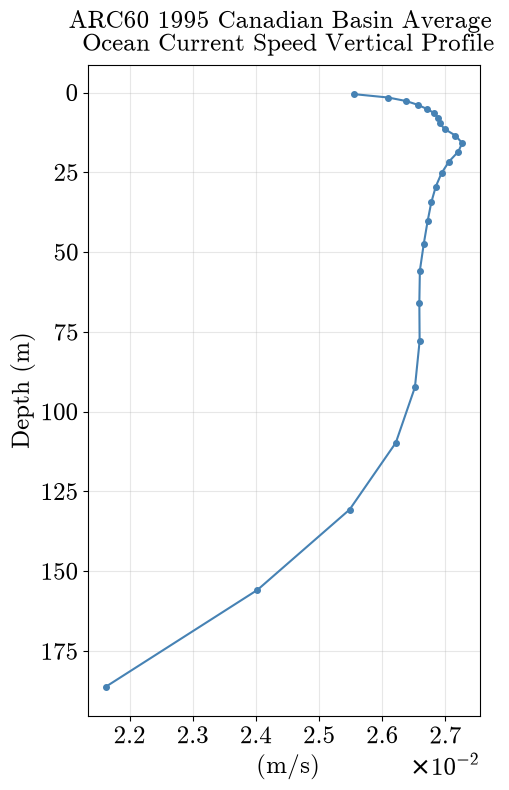

(<Figure size 500x800 with 1 Axes>,
 <Axes: title={'center': 'ARC60 1995 Canadian Basin Average \n Ocean Current Speed Vertical Profile'}, xlabel=' (m/s)', ylabel='Depth (m)'>)

In [24]:
graphVerticalProfile('vprofile_speed_1995.npz')

In [5]:
# =============================================================================
# CELL 4 — TIMESERIES GRAPH FUNCTION (1994–1999 multi-year)
# =============================================================================

def _load_multiyear_timeseries(field_name, depth=None, integrated=False,
                                year_start=1994, year_end=1999):
    """
    Load and concatenate annual timeseries files for a given field/depth
    across year_start to year_end. Returns sorted dates and values arrays.
    """
    all_dates  = []
    all_values = []

    for year in range(year_start, year_end + 1):
        if field_name == 'fwt348':
            fname = PROCESSED_DIR / f"timeseries_fwt_{year}.npz"
        else:
            suffix = '_int' if integrated else ''
            prefix = 'speed' if field_name == 'speed' else 'eke'
            fname  = PROCESSED_DIR / f"timeseries_{prefix}_{year}_{depth}{suffix}.npz"

        if not fname.exists():
            print(f"  Missing: {fname.name} — skipping")
            continue

        f = np.load(fname)
        all_dates.extend([datetime.strptime(str(d), '%Y-%m-%d') for d in f['dates']])
        all_values.extend(f['values'].tolist())

    if not all_dates:
        raise FileNotFoundError(f"No timeseries files found for {field_name} depth={depth}")

    # sort chronologically in case files were loaded out of order
    sorted_pairs = sorted(zip(all_dates, all_values))
    dates  = [p[0] for p in sorted_pairs]
    values = np.array([p[1] for p in sorted_pairs], dtype=np.float64)
    return dates, values


def _running_average(dt_dates, values, window_days):
    """
    Centered running average over a fixed window of calendar days.
    Uses pandas for speed — much faster than the manual loop.
    """
    values = np.asarray(values, dtype=np.float64)
    s = pd.Series(values, index=pd.DatetimeIndex(dt_dates))
    half = window_days // 2
    running = s.rolling(window=window_days, center=True, min_periods=half).mean()
    return running.values


def graphTimeseriesMultiyear(
    field_name,
    depth=None,
    integrated=False,
    year_start=1994,
    year_end=1999,
    color='C0',
    linewidth=0.8,
    alpha_daily=0.4,
    show_monthly=True,
    monthly_color='steelblue',
    monthly_linewidth=1.8,
    show_annual_means=True,
    annual_mean_color='black',
    annual_mean_linewidth=2.0,
    show_mean=True,
    mean_color='red',
    vmin=None,
    vmax=None,
    show=True,
    save=False,
):
    """
    Plot a multi-year daily timeseries (1994–1999) for a given variable/depth,
    with 30-day and 365-day centered running averages overlaid.

    Parameters
    ----------
    field_name   : str — 'speed', 'fwt348', or 'EKE'
    depth        : int or None — depth level (ignored for fwt348)
    integrated   : bool — use integrated files (ignored for fwt348)
    year_start / year_end : int
    color        : str — daily line color
    linewidth    : float — daily line width
    alpha_daily  : float — daily line transparency
    show_monthly : bool — overlay 30-day running average
    monthly_color, monthly_linewidth
    show_yearly  : bool — overlay 365-day running average
    yearly_color, yearly_linewidth
    show_mean    : bool — draw horizontal period mean line
    mean_color   : str
    vmin / vmax  : float or None — y-axis limits (auto if None)
    show         : bool
    save         : bool — saves to ../figures/
    """
    # ── validate ──────────────────────────────────────────────────────────────
    if field_name not in _FIELD_META:
        raise ValueError(f"field_name must be one of {list(_FIELD_META.keys())}")
    if field_name != 'fwt348' and depth is None:
        raise ValueError("depth must be specified for speed and EKE")

    finfo = _FIELD_META[field_name]

    # ── load and concatenate timeseries ───────────────────────────────────────
    print(f"Loading timeseries: {field_name}  depth={depth}  integrated={integrated}")
    dates, values = _load_multiyear_timeseries(
        field_name, depth=depth, integrated=integrated,
        year_start=year_start, year_end=year_end
    )
    print(f"  {len(dates)} daily values loaded ({dates[0].date()} → {dates[-1].date()})")

    # ── running averages ──────────────────────────────────────────────────────
    monthly = _running_average(dates, values, window_days=30)   if show_monthly else None
    
    # ── title ─────────────────────────────────────────────────────────────────
    if field_name == 'fwt348':
        depth_str = ''
    elif depth == 0:
        depth_str = 'At Surface'
    elif not integrated:
        depth_str = f'At {depth} m Depth'
    else:
        lo, hi = DEPTH_BOUNDARIES[int(depth)]
        depth_str = f'From {lo} to {hi} m Depth'

    period_str = f'{year_start} to {year_end}'
    title = ' '.join(p for p in [
        'ARC60', period_str, 'Average', finfo['label'], depth_str, '(Canadian Basin)'
    ] if p)

    # ── figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 5))

    # daily
    ax.plot(dates, values, color=color, linewidth=linewidth,
            alpha=alpha_daily, label='Daily')

    # monthly running average
    if show_monthly:
        ax.plot(dates, monthly, color=monthly_color,
                linewidth=monthly_linewidth, label='30-day running average')
    
    # annual means
    if show_annual_means:
        dates_arr = np.array(dates)
        values_arr = np.array(values)
        first = True
        for year in range(year_start, year_end + 1):
            year_mask = np.array([d.year == year for d in dates])
            year_vals = values_arr[year_mask]
            year_dates = dates_arr[year_mask]
            if not np.any(np.isfinite(year_vals)):
                continue
            ymean = np.nanmean(year_vals)
            ax.hlines(ymean,
                      xmin=year_dates[0], xmax=year_dates[-1],
                      colors=annual_mean_color, linewidth=annual_mean_linewidth,
                      label='Annual mean' if first else None)
            first = False

    # period mean horizontal line
    if show_mean:
        valid_mean = np.nanmean(values)
        ax.axhline(valid_mean, color=mean_color, linestyle='--', linewidth=1.2,
                   label=f'Period mean = {valid_mean:.4f}')

    # year boundary vertical lines
    for year in range(year_start + 1, year_end + 1):
        ax.axvline(datetime(year, 1, 1), color='gray', linewidth=0.5,
                   linestyle=':', alpha=0.6)

    if vmin is not None or vmax is not None:
        ax.set_ylim(vmin, vmax)

    ax.set_xlabel('Date', fontsize=14)
    ax.set_ylabel(finfo['unit'], fontsize=14)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    ax.set_title(title, fontsize=16, pad=10)
    ax.legend(fontsize=13, loc='upper left')
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()

    # ── save ──────────────────────────────────────────────────────────────────
    if save:
        suffix  = '_int' if integrated else ''
        depth_s = '' if field_name == 'fwt348' else f'_{depth}{suffix}'
        fname   = FIGURES_DIR / f"timeseries_{field_name}{depth_s}_{year_start}_{year_end}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax


# ── USAGE ─────────────────────────────────────────────────────────────────────
# graphTimeseriesMultiyear('speed', depth=0)
# graphTimeseriesMultiyear('speed', depth=50, integrated=True)
# graphTimeseriesMultiyear('fwt348')
# graphTimeseriesMultiyear('EKE', depth=100, integrated=True, save=True)
# graphTimeseriesMultiyear('speed', depth=200, integrated=True,
#                           show_monthly=True, show_yearly=True, save=True)

Loading timeseries: fwt348  depth=50  integrated=True
  2186 daily values loaded (1994-01-01 → 1999-12-31)


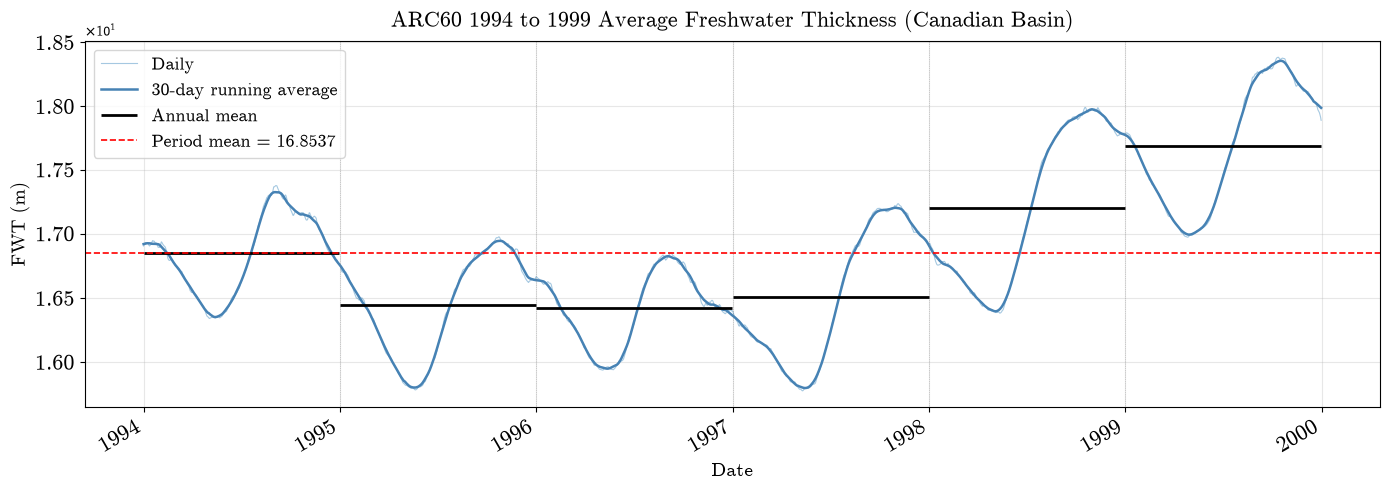

(<Figure size 1400x500 with 1 Axes>,
 <Axes: title={'center': 'ARC60 1994 to 1999 Average Freshwater Thickness (Canadian Basin)'}, xlabel='Date', ylabel='FWT (m)'>)

In [73]:
graphTimeseriesMultiyear('fwt348', depth=50, integrated=True, show=True, save=False)

In [ ]:
# =============================================================================
# CELL — GRAPH ALL MISSING FIGURES (fields + complete timeseries)
# =============================================================================

# ── 1. spatial field figures ──────────────────────────────────────────────────
all_npz = sorted(
    f for f in PROCESSED_DIR.glob("*.npz")
    if not f.stem.startswith('timeseries_')
    and f.stem != 'grid'
    and f.stem != 'common_data'
)
missing_fields = [f for f in all_npz if not (FIGURES_DIR / f"{f.stem}.png").exists()]

print(f"Spatial field files  : {len(all_npz)}")
print(f"Already plotted      : {len(all_npz) - len(missing_fields)}")
print(f"Missing field figures: {len(missing_fields)}")
for f in missing_fields:
    print(f"  {f.name}")

print()
for f in tqdm(missing_fields, desc="Plotting missing field figures"):
    try:
        graphFunction(f.stem, save=True, show=False)
    except Exception as e:
        print(f"  ⚠ Failed on {f.name}: {e}")

# ── 2. multi-year timeseries figures ─────────────────────────────────────────
# define all expected timeseries configurations
_TS_CONFIGS = []

# speed: all depths, non-integrated and integrated
for depth in TARGET_DEPTHS:
    _TS_CONFIGS.append(('speed', depth, False))
    if depth > 0:
        _TS_CONFIGS.append(('speed', depth, True))

# EKE: all depths, non-integrated and integrated
for depth in TARGET_DEPTHS:
    _TS_CONFIGS.append(('EKE', depth, False))
    if depth > 0:
        _TS_CONFIGS.append(('EKE', depth, True))

# fwt: no depth
_TS_CONFIGS.append(('fwt348', None, False))

# check which configs have all 6 annual files present AND no figure yet
YEAR_START, YEAR_END = 1994, 1999

missing_ts = []
for field_name, depth, integrated in _TS_CONFIGS:
    suffix  = '_int' if integrated else ''
    depth_s = '' if field_name == 'fwt348' else f'_{depth}{suffix}'

    # check all annual timeseries files exist
    all_present = True
    for year in range(YEAR_START, YEAR_END + 1):
        if field_name == 'fwt348':
            fname = PROCESSED_DIR / f"timeseries_fwt_{year}.npz"
        else:
            prefix = 'speed' if field_name == 'speed' else 'eke'
            fname  = PROCESSED_DIR / f"timeseries_{prefix}_{year}_{depth}{suffix}.npz"
        if not fname.exists():
            all_present = False
            break

    if not all_present:
        continue

    # check figure doesn't already exist
    fig_path = FIGURES_DIR / f"timeseries_{field_name}{depth_s}_{YEAR_START}_{YEAR_END}.png"
    if not fig_path.exists():
        missing_ts.append((field_name, depth, integrated, fig_path))

print(f"\nComplete timeseries configs : {len([c for c in _TS_CONFIGS])}")
print(f"Missing timeseries figures  : {len(missing_ts)}")
for _, _, _, fig_path in missing_ts:
    print(f"  {fig_path.name}")

print()
for field_name, depth, integrated, fig_path in tqdm(missing_ts, desc="Plotting missing timeseries"):
    try:
        graphTimeseriesMultiyear(
            field_name, depth=depth, integrated=integrated,
            year_start=YEAR_START, year_end=YEAR_END,
            save=True, show=False,
        )
    except Exception as e:
        print(f"  ⚠ Failed on {fig_path.name}: {e}")

# ── 3. vertical profile figures ───────────────────────────────────────────────
all_vprofile_npz = sorted(PROCESSED_DIR.glob("vprofile_*.npz"))
missing_vprofiles = [
    f for f in all_vprofile_npz
    if not (FIGURES_DIR / f"{f.stem}.png").exists()
]
print(f"\nVertical profile files   : {len(all_vprofile_npz)}")
print(f"Already plotted          : {len(all_vprofile_npz) - len(missing_vprofiles)}")
print(f"Missing profile figures  : {len(missing_vprofiles)}")
for f in missing_vprofiles:
    print(f"  {f.name}")
print()
for f in tqdm(missing_vprofiles, desc="Plotting missing profile figures"):
    try:
        graphVerticalProfile(f.stem, save=True, show=False)
    except Exception as e:
        print(f"  ⚠ Failed on {f.name}: {e}")

Spatial field files  : 130
Already plotted      : 44
Missing field figures: 86
  speed_1994_200_int.npz
  speed_1994_50.npz
  speed_1994_50_int.npz
  speed_1995_0.npz
  speed_1995_100.npz
  speed_1995_100_int.npz
  speed_1995_200.npz
  speed_1995_200_int.npz
  speed_1995_50.npz
  speed_1995_50_int.npz
  speed_1996_0.npz
  speed_1996_100.npz
  speed_1996_100_int.npz
  speed_1996_200.npz
  speed_1996_200_int.npz
  speed_1996_50.npz
  speed_1996_50_int.npz
  speed_1997_0.npz
  speed_1997_100.npz
  speed_1997_100_int.npz
  speed_1997_200.npz
  speed_1997_200_int.npz
  speed_1997_50.npz
  speed_1997_50_int.npz
  speed_1998_0.npz
  speed_1998_100.npz
  speed_1998_100_int.npz
  speed_1998_200.npz
  speed_1998_200_int.npz
  speed_1998_50.npz
  speed_1998_50_int.npz
  speed_1999_0.npz
  speed_1999_100.npz
  speed_1999_100_int.npz
  speed_1999_200.npz
  speed_1999_200_int.npz
  speed_1999_50.npz
  speed_1999_50_int.npz
  speed_AMJ_0.npz
  speed_AMJ_100.npz
  speed_AMJ_100_int.npz
  speed_AMJ_200

Plotting missing field figures:   0%|                   | 0/86 [00:00<?, ?it/s]

Loading speed_1994_200_int.npz ...
Loading cached triangulation from triangulation_step4_2865x3489.pkl ...


Plotting missing field figures:   1%|        | 1/86 [03:33<5:02:04, 213.23s/it]

Figure saved → ../figures/speed_1994_200_int.png
Loading speed_1994_50.npz ...


...

Figure saved → ../figures/speed_1995_50.png
Loading speed_1995_50_int.npz ...


Plotting missing field figures:  12%|▊      | 10/86 [43:43<7:44:39, 366.83s/it]

Figure saved → ../figures/speed_1995_50_int.png
Loading speed_1996_0.npz ...


Plotting missing field figures:  13%|▉      | 11/86 [49:01<7:19:33, 351.64s/it]

Figure saved → ../figures/speed_1996_0.png
Loading speed_1996_100.npz ...
